Reading AC scan data: D:\eBATS\data\C0010\C0004R02_PARK25_AC_1D_SCAN.xlsx
Reading LC scan data: D:\eBATS\data\C0010\C0003R03_PARK25_LC_1D_SCAN.xlsx

Selected-case check against scan files:
  AC scan: Tmax = 44.787 degC, DeltaTmax = 3.508 degC, mass = 0.596 kg
  LC scan: Tmax = 36.134 degC, DeltaTmax = 3.189 degC, mass = 1.19547 kg

Comparison values used for the radar chart:
Configuration                 Tmax (degC)   DeltaTmax (degC)    Mass (kg)     Eaux (J)
AC Baseline                        48.470              2.036      0.74500        0.000
Selected AC                        44.787              3.508      0.59600     1370.000
Selected Liquid Cooling            36.134              3.189      1.19547        6.474

Best raw values used for normalization:
  Tmax       = 36.134 degC
  DeltaTmax  = 2.036 degC
  Mass       = 0.59600 kg

Normalized radar scores:
Configuration                        Tmax    DeltaTmax         Mass
AC Baseline                         0.745        1.000      

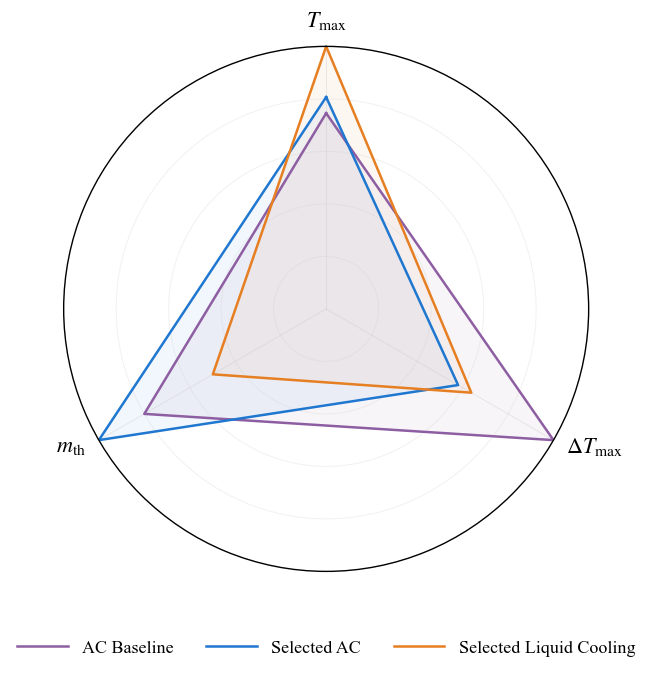


Saved radar PNG: D:\eBATS\out\C0010\C0010_BTMS_radar_ACbaseline_ACselected_LCselected.png
Saved radar PDF: D:\eBATS\out\C0010\C0010_BTMS_radar_ACbaseline_ACselected_LCselected.pdf


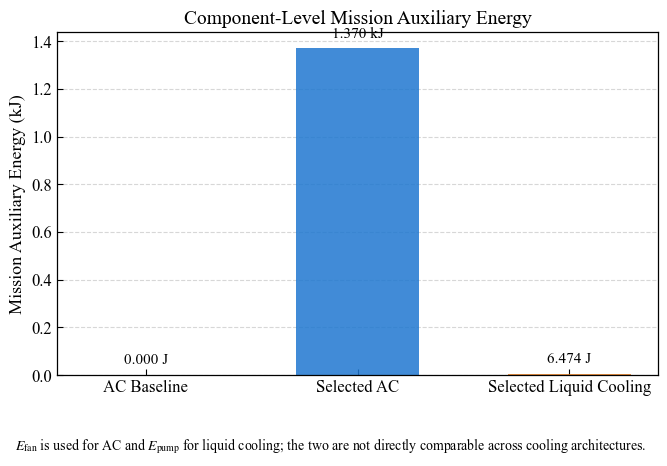


Saved energy PNG: D:\eBATS\out\C0010\C0010_BTMS_auxiliary_energy_reference.png
Saved energy PDF: D:\eBATS\out\C0010\C0010_BTMS_auxiliary_energy_reference.pdf


In [5]:
# ============================================================
# C0010R06_PARK25_ACLC_1D_CMP_plot_radar.py
# BTMS performance comparison:
# AC Baseline vs. Selected AC vs. Selected Liquid Cooling
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. File settings
# ============================================================

PROJECT_ROOT = r'D:\eBATS'
CASE_ID = 'C0010'

AC_FILE_NAME = 'C0004R02_PARK25_AC_1D_SCAN.xlsx'
LC_FILE_NAME = 'C0003R03_PARK25_LC_1D_SCAN.xlsx'

AC_FILE = os.path.join(PROJECT_ROOT, 'data', CASE_ID, AC_FILE_NAME)
LC_FILE = os.path.join(PROJECT_ROOT, 'data', CASE_ID, LC_FILE_NAME)

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RADAR_PNG_FILE = os.path.join(OUTPUT_DIR, 'C0010_BTMS_radar_ACbaseline_ACselected_LCselected.png')
RADAR_PDF_FILE = os.path.join(OUTPUT_DIR, 'C0010_BTMS_radar_ACbaseline_ACselected_LCselected.pdf')
ENERGY_PNG_FILE = os.path.join(OUTPUT_DIR, 'C0010_BTMS_auxiliary_energy_reference.png')
ENERGY_PDF_FILE = os.path.join(OUTPUT_DIR, 'C0010_BTMS_auxiliary_energy_reference.pdf')

# ============================================================
# 2. Comparison results from C0008 and C0009
# ============================================================

# AC baseline:
# V_air = 1.5 m/s
# T_air = 25 degC
# s_gap = 4.5 mm
# cruise-only cooling
AC_BASELINE = {'Tmax_C': 48.470, 'DeltaTmax_C': 2.036, 'mass_kg': 0.745, 'E_aux_J': 0.0}

# Selected AC:
# V_air = 1.5 m/s
# T_air = 25 degC
# s_gap = 2.0 mm
# all-mission cooling
AC_SELECTED = {'Tmax_C': 44.787, 'DeltaTmax_C': 3.508, 'mass_kg': 0.596, 'E_aux_J': 1370.0}

# Selected liquid cooling:
# T_cool,in = 25 degC
# m_dot_total = 0.045 kg/s
# N_ch = 32
# W_ch = 10 mm
# H_ch = 3 mm
# L_ch = 380 mm
LC_SELECTED = {'Tmax_C': 36.134, 'DeltaTmax_C': 3.189, 'mass_kg': 1.19547, 'E_aux_J': 6.474}

CASE_NAMES = ['AC Baseline', 'Selected AC', 'Selected Liquid Cooling']
CASE_RESULTS = [AC_BASELINE, AC_SELECTED, LC_SELECTED]

# ============================================================
# 3. Selected parameters used to verify scan files
# ============================================================

AC_T_AIR = 25.0
AC_V_AIR = 1.50
AC_S_GAP = 2.0

LC_W_CHANNEL = 10.0
LC_H_CHANNEL = 3.0
LC_L_CHANNEL = 380.0
LC_NUM_CHANNELS = 32
LC_M_DOT_TOTAL = 0.045
LC_M_DOT_CHANNEL = LC_M_DOT_TOTAL / LC_NUM_CHANNELS

# ============================================================
# 4. Read scan files
# ============================================================

if not os.path.isfile(AC_FILE):
    raise FileNotFoundError(f'AC scan file not found: {AC_FILE}')

if not os.path.isfile(LC_FILE):
    raise FileNotFoundError(f'LC scan file not found: {LC_FILE}')

print(f'Reading AC scan data: {AC_FILE}')
print(f'Reading LC scan data: {LC_FILE}')

ac_data = pd.read_excel(AC_FILE)
lc_data = pd.read_excel(LC_FILE)

# ============================================================
# 5. Verify selected AC case
# ============================================================

ac_selected_scan = ac_data[np.isclose(ac_data['T_air_in_C'], AC_T_AIR) & np.isclose(ac_data['V_air_m_s'], AC_V_AIR) & np.isclose(ac_data['s_gap_mm'], AC_S_GAP)].copy()

if len(ac_selected_scan) != 1:
    raise ValueError(f'Expected one selected AC case in the scan file, but found {len(ac_selected_scan)}.')

ac_selected_scan = ac_selected_scan.iloc[0]

# ============================================================
# 6. Verify selected liquid-cooling case
# ============================================================

lc_selected_scan = lc_data[np.isclose(lc_data['W_channel_mm'], LC_W_CHANNEL) & np.isclose(lc_data['H_channel_mm'], LC_H_CHANNEL) & np.isclose(lc_data['L_channel_mm'], LC_L_CHANNEL) & np.isclose(lc_data['num_parallel_channels'], LC_NUM_CHANNELS) & np.isclose(lc_data['m_dot_channel_kg_s'], LC_M_DOT_CHANNEL)].copy()

if len(lc_selected_scan) != 1:
    raise ValueError(f'Expected one selected liquid-cooling case in the scan file, but found {len(lc_selected_scan)}.')

lc_selected_scan = lc_selected_scan.iloc[0]

# ============================================================
# 7. Print selected-case checks
# ============================================================

print()
print('Selected-case check against scan files:')
print(f"  AC scan: Tmax = {float(ac_selected_scan['Tmax_mission_C']):.3f} degC, DeltaTmax = {float(ac_selected_scan['DeltaT_mission_max_C']):.3f} degC, mass = {float(ac_selected_scan['m_bottom_plate_kg']):.3f} kg")
print(f"  LC scan: Tmax = {float(lc_selected_scan['Tmax_mission_C']):.3f} degC, DeltaTmax = {float(lc_selected_scan['DeltaT_mission_max_C']):.3f} degC, mass = {float(lc_selected_scan['mtotal']):.5f} kg")

# ============================================================
# 8. Print comparison values
# ============================================================

print()
print('Comparison values used for the radar chart:')
print(f"{'Configuration':<28s} {'Tmax (degC)':>12s} {'DeltaTmax (degC)':>18s} {'Mass (kg)':>12s} {'Eaux (J)':>12s}")

for name, result in zip(CASE_NAMES, CASE_RESULTS):
    print(f"{name:<28s} {result['Tmax_C']:>12.3f} {result['DeltaTmax_C']:>18.3f} {result['mass_kg']:>12.5f} {result['E_aux_J']:>12.3f}")

# ============================================================
# 9. Radar normalization
# Only the three configurations shown in the radar chart are
# used for normalization.
#
# All metrics are "smaller is better":
# score(i,j) = min(x_j) / x(i,j)
#
# Therefore the best configuration for each metric = 1.0.
# ============================================================

raw_metrics = np.array([[AC_BASELINE['Tmax_C'], AC_BASELINE['DeltaTmax_C'], AC_BASELINE['mass_kg']], [AC_SELECTED['Tmax_C'], AC_SELECTED['DeltaTmax_C'], AC_SELECTED['mass_kg']], [LC_SELECTED['Tmax_C'], LC_SELECTED['DeltaTmax_C'], LC_SELECTED['mass_kg']]], dtype=float)
best_metrics = np.min(raw_metrics, axis=0)
score_metrics = best_metrics / raw_metrics

RADAR_SCORES = {}

for i, name in enumerate(CASE_NAMES):
    RADAR_SCORES[name] = score_metrics[i, :].tolist()

print()
print('Best raw values used for normalization:')
print(f'  Tmax       = {best_metrics[0]:.3f} degC')
print(f'  DeltaTmax  = {best_metrics[1]:.3f} degC')
print(f'  Mass       = {best_metrics[2]:.5f} kg')

print()
print('Normalized radar scores:')
print(f"{'Configuration':<28s} {'Tmax':>12s} {'DeltaTmax':>12s} {'Mass':>12s}")

for name in CASE_NAMES:
    score = RADAR_SCORES[name]
    print(f'{name:<28s} {score[0]:>12.3f} {score[1]:>12.3f} {score[2]:>12.3f}')

# ============================================================
# 10. Scientific plot style
# ============================================================

font_size = 12

plt.rcdefaults()
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'stix', 'font.size': font_size, 'axes.labelsize': font_size, 'axes.titlesize': font_size, 'xtick.labelsize': font_size, 'ytick.labelsize': font_size, 'axes.linewidth': 0.9, 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.major.width': 0.8, 'ytick.major.width': 0.8, 'xtick.major.size': 4, 'ytick.major.size': 4, 'axes.unicode_minus': False})

# ============================================================
# 11. Radar chart
# ============================================================

categories = [r'$T_{\max}$', r'$\Delta T_{\max}$', r'$m_{\mathrm{th}}$']
angles = np.linspace(0.0, 2.0 * np.pi, len(categories), endpoint=False).tolist()
angles_closed = angles + angles[:1]

plot_styles = {'AC Baseline': {'color': '#8E5EA2', 'alpha': 0.06}, 'Selected AC': {'color': '#1F77D0', 'alpha': 0.06}, 'Selected Liquid Cooling': {'color': '#E67E22', 'alpha': 0.06}}

fig = plt.figure(figsize=(7.0, 7.0))
ax = fig.add_subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2.0)
ax.set_theta_direction(-1)
ax.set_ylim(0.0, 1.0)
ax.set_xticks(angles)
ax.set_xticklabels(['', '', ''])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.xaxis.grid(True, linewidth=0.7, color='0.78', alpha=0.35)
ax.yaxis.grid(True, linewidth=0.7, color='0.82', alpha=0.30)
ax.spines['polar'].set_linewidth(1.0)

# Solid lines, different colors, no markers.
for name in CASE_NAMES:
    values = RADAR_SCORES[name] + RADAR_SCORES[name][:1]
    style = plot_styles[name]
    ax.plot(angles_closed, values, color=style['color'], linewidth=1.8, linestyle='-', label=name)
    ax.fill(angles_closed, values, color=style['color'], alpha=style['alpha'])

# Metric symbols outside the outer circle.
ax.text(angles[0], 1.055, r'$T_{\max}$', ha='center', va='bottom', fontsize=font_size + 4, clip_on=False)
ax.text(angles[1], 1.055, r'$\Delta T_{\max}$', ha='left', va='center', fontsize=font_size + 4, clip_on=False)
ax.text(angles[2], 1.055, r'$m_{\mathrm{th}}$', ha='right', va='center', fontsize=font_size + 4, clip_on=False)

# Bottom horizontal legend.
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=False, fontsize=font_size + 1, handlelength=2.8, columnspacing=1.8)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.18)

plt.savefig(RADAR_PNG_FILE, dpi=900, bbox_inches='tight')
plt.savefig(RADAR_PDF_FILE, dpi=900, bbox_inches='tight')
plt.show()

print()
print(f'Saved radar PNG: {RADAR_PNG_FILE}')
print(f'Saved radar PDF: {RADAR_PDF_FILE}')

# ============================================================
# 12. Component-level mission auxiliary energy
# AC uses E_fan and liquid cooling uses E_pump.
# These are shown separately because the system boundaries differ.
# ============================================================

energy_J = np.array([result['E_aux_J'] for result in CASE_RESULTS], dtype=float)
energy_kJ = energy_J / 1000.0
energy_colors = [plot_styles[name]['color'] for name in CASE_NAMES]

fig, ax = plt.subplots(figsize=(7.2, 4.8))

x = np.arange(len(CASE_NAMES))
bars = ax.bar(x, energy_kJ, width=0.58, color=energy_colors, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CASE_NAMES)
ax.set_ylabel('Mission Auxiliary Energy (kJ)', fontsize=font_size + 1)
ax.set_title('Component-Level Mission Auxiliary Energy', fontsize=font_size + 2)
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_axisbelow(True)

energy_max = max(float(np.max(energy_kJ)), 1.0)

for bar, value_kJ, value_J in zip(bars, energy_kJ, energy_J):
    y_text = value_kJ + 0.025 * energy_max
    label = f'{value_kJ:.3f} kJ' if value_kJ >= 0.1 else f'{value_J:.3f} J'
    ax.text(bar.get_x() + bar.get_width() / 2.0, y_text, label, ha='center', va='bottom', fontsize=font_size - 1)

fig.text(0.50, 0.022, r'$E_{\mathrm{fan}}$ is used for AC and $E_{\mathrm{pump}}$ for liquid cooling; the two are not directly comparable across cooling architectures.', ha='center', va='center', fontsize=font_size - 2)

plt.tight_layout(rect=[0.03, 0.09, 0.98, 0.97])

plt.savefig(ENERGY_PNG_FILE, dpi=600, bbox_inches='tight')
plt.savefig(ENERGY_PDF_FILE, dpi=600, bbox_inches='tight')
plt.show()

print()
print(f'Saved energy PNG: {ENERGY_PNG_FILE}')
print(f'Saved energy PDF: {ENERGY_PDF_FILE}')
